# SPRT‑TANDEM Real‑Time EMG Aggression DetectionRaw 8‑channel sEMG stream – binary classification (Aggressive vs Normal) – Early stopping via Wald's SPRTFaithful to Ebihara et al. ICLR 2021 & official PyTorch implementation

In [1]:
import os, math, time, random, warnings, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             confusion_matrix, recall_score, precision_score,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import kagglehub

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
path = kagglehub.dataset_download("durgancegaur/emg-physical-action-data-set")
print("Path to dataset files:", path)

100%|██████████| 23.1M/23.1M [00:00<00:00, 54.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/durgancegaur/emg-physical-action-data-set/versions/2


## Configuration and Data Loading

In [3]:
DATA_DIR     = path
SLICE_LEN    = 128
SLICE_STRIDE = 64
T            = 20
FEAT_DIM     = 128
ORDER        = 5
NUM_CLASSES  = 2
WIDTH_LSTM   = 64
DROPOUT      = 0.1
BATCH_SIZE   = 64
PHASE1_BATCH = 256
LR1          = 1e-3
LR2          = 1e-4
W_MCE        = 0.6
W_LSEL       = 0.3
MAX_NORM     = 50000.0
PATIENCE1    = 10
PATIENCE2    = 80

TRAIN_SUBJECTS = ['sub','sub1','sub2']
VAL_SUBJECTS   = ['sub3']
TEST_SUBJECTS  = ['sub4']

In [5]:
def load_subject_data(root, sub_id):
    pairs = []
    sub_dir = os.path.join(root, sub_id)
    if not os.path.isdir(sub_dir):
        print(f"  {sub_id}: directory not found")
        return pairs

    for act_type in ("Aggressive", "Normal"):
        type_dir = os.path.join(sub_dir, act_type)
        if not os.path.isdir(type_dir):
            continue
        lbl = 1 if act_type == "Aggressive" else 0

        if sub_id == "sub":
            for fpath in glob.glob(os.path.join(type_dir, "*.csv")):
                df = pd.read_csv(fpath, usecols=range(8))
                sig = df.values.astype(np.float32)
                if len(sig) > 0:
                    pairs.append((sig, lbl))
        else:
            txt_dir = os.path.join(type_dir, "txt")
            if not os.path.isdir(txt_dir):
                continue
            for fpath in glob.glob(os.path.join(txt_dir, "*.txt")):
                try:
                    sig = np.loadtxt(fpath).astype(np.float32)
                except:
                    sig = pd.read_csv(fpath, delim_whitespace=True, header=None).values.astype(np.float32)
                if sig.ndim == 1:
                    sig = sig.reshape(-1, 1)
                if sig.shape[1] != 8:
                    if sig.shape[1] > 8:
                        sig = sig[:, :8]
                else:
                    pad_w = 8 - sig.shape[1]
                    sig = np.pad(sig, ((0,0),(0,pad_w)), 'constant')
                pairs.append((sig, lbl))
    return pairs

all_data = {}
for sid in ["sub","sub1","sub2","sub3","sub4"]:
    data = load_subject_data(DATA_DIR, sid)
    if data:
        all_data[sid] = data
        ex_sig, ex_lbl = data[0]
        print(f"{sid}: {len(data)} recordings | first shape: {ex_sig.shape} | label: {ex_lbl}")
    else:
        print(f"{sid}: NO DATA FOUND")

sub: 20 recordings | first shape: (9550, 8) | label: 1
sub1: 20 recordings | first shape: (9772, 8) | label: 1
sub2: 20 recordings | first shape: (10000, 8) | label: 1
sub3: 20 recordings | first shape: (9794, 8) | label: 1
sub4: 20 recordings | first shape: (9574, 8) | label: 1


## Slice, Build Sequences, Split by Subject, and Scale

In [6]:
def process_subjects(sub_list):
    slices_list, slice_y_list = [], []
    seqs_list, seq_y_list = [], []
    for sid in sub_list:
        if sid not in all_data:
            continue
        for sig, lbl in all_data[sid]:
            n_win = max(0, (sig.shape[0] - SLICE_LEN) // SLICE_STRIDE + 1)
            if n_win == 0:
                continue
            idx = np.arange(n_win) * SLICE_STRIDE
            slic = np.stack([sig[i:i+SLICE_LEN] for i in idx])
            slices_list.append(slic)
            slice_y_list.append(np.full(n_win, lbl, dtype=np.int64))
            if n_win >= T:
                seqs = np.stack([slic[i:i+T] for i in range(n_win - T + 1)])
                seqs_list.append(seqs)
                seq_y_list.append(np.full(len(seqs), lbl, dtype=np.int64))
    X_sl = np.concatenate(slices_list, axis=0) if slices_list else np.empty((0, SLICE_LEN, 8), dtype=np.float32)
    y_sl = np.concatenate(slice_y_list, axis=0) if slice_y_list else np.empty((0,), dtype=np.int64)
    X_sq = np.concatenate(seqs_list, axis=0) if seqs_list else np.empty((0, T, SLICE_LEN, 8), dtype=np.float32)
    y_sq = np.concatenate(seq_y_list, axis=0) if seq_y_list else np.empty((0,), dtype=np.int64)
    return X_sl, y_sl, X_sq, y_sq

X_train_sl, y_train_sl, X_train_seq, y_train_seq = process_subjects(TRAIN_SUBJECTS)
X_val_sl,   y_val_sl,   X_val_seq,   y_val_seq   = process_subjects(VAL_SUBJECTS)
X_test_sl,  y_test_sl,  X_test_seq,  y_test_seq  = process_subjects(TEST_SUBJECTS)

print(f"Train slices: {X_train_sl.shape[0]:,} | class balance: {np.bincount(y_train_sl)}")
print(f"Val   slices: {X_val_sl.shape[0]:,}   | class balance: {np.bincount(y_val_sl)}")
print(f"Test  slices: {X_test_sl.shape[0]:,}   | class balance: {np.bincount(y_test_sl)}")
print(f"Train seqs  : {X_train_seq.shape[0]:,} | class balance: {np.bincount(y_train_seq)}")
print(f"Val   seqs  : {X_val_seq.shape[0]:,}   | class balance: {np.bincount(y_val_seq)}")
print(f"Test  seqs  : {X_test_seq.shape[0]:,}   | class balance: {np.bincount(y_test_seq)}")

X_test_raw_seq = X_test_seq.copy()

scaler = StandardScaler().fit(X_train_sl.reshape(-1, 8))
def scale_data(X):
    orig_shape = X.shape
    return scaler.transform(X.reshape(-1, 8)).reshape(orig_shape)

X_train_sl  = scale_data(X_train_sl)
X_val_sl    = scale_data(X_val_sl)
X_test_sl   = scale_data(X_test_sl)
X_train_seq = scale_data(X_train_seq)
X_val_seq   = scale_data(X_val_seq)
X_test_seq  = scale_data(X_test_seq)
print("Scaling complete.")

Train slices: 9,126 | class balance: [4583 4543]
Val   slices: 3,160   | class balance: [1542 1618]
Test  slices: 3,043   | class balance: [1530 1513]
Train seqs  : 7,986 | class balance: [4013 3973]
Val   seqs  : 2,780   | class balance: [1352 1428]
Test  seqs  : 2,663   | class balance: [1340 1323]
Scaling complete.


## Phase 1 – Per‑Slice CNN Feature Extractor

In [7]:
class SliceCNN(nn.Module):
    def __init__(self, in_channels=8, feat_dim=FEAT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(in_channels, 32, 7, padding=3, stride=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, 5, stride=2, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, feat_dim, 5, stride=2, padding=2),
            nn.BatchNorm1d(feat_dim), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.head = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feats = self.backbone(x).squeeze(-1)
        logits = self.head(feats)
        return logits, feats

train_X_sl = torch.tensor(X_train_sl, dtype=torch.float32).permute(0,2,1)
train_Y_sl = torch.tensor(y_train_sl, dtype=torch.long)
val_X_sl   = torch.tensor(X_val_sl, dtype=torch.float32).permute(0,2,1)
val_Y_sl   = torch.tensor(y_val_sl, dtype=torch.long)

phase1_train_loader = DataLoader(TensorDataset(train_X_sl, train_Y_sl),
                                 batch_size=PHASE1_BATCH, shuffle=True)
phase1_val_loader   = DataLoader(TensorDataset(val_X_sl, val_Y_sl),
                                 batch_size=PHASE1_BATCH, shuffle=False)

cnn = SliceCNN().to(device)
opt1 = optim.Adam(cnn.parameters(), lr=LR1, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

best_val_bacc = 0.0
patience_counter = 0
for epoch in range(30):
    cnn.train()
    for xb, yb in phase1_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt1.zero_grad()
        logits, _ = cnn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt1.step()
    cnn.eval()
    all_preds = []
    with torch.no_grad():
        for xb, yb in phase1_val_loader:
            logits, _ = cnn(xb.to(device))
            all_preds.append(logits.argmax(1).cpu().numpy())
    val_bacc = balanced_accuracy_score(val_Y_sl.numpy(), np.concatenate(all_preds))
    if val_bacc - best_val_bacc > 0.001:
        best_val_bacc = val_bacc; patience_counter = 0
        torch.save(cnn.state_dict(), 'best_cnn_emg.pth')
    else:
        patience_counter += 1
    if (epoch + 1) % 5 == 0:
        print(f"Phase1 Epoch {epoch+1:2d}: val bacc={val_bacc:.4f} (best={best_val_bacc:.4f})")
    if patience_counter >= PATIENCE1:
        print(f"Early stopping at epoch {epoch+1}")
        break

cnn.load_state_dict(torch.load('best_cnn_emg.pth'))
cnn.eval()
print(f"Best Phase1 val bacc: {best_val_bacc:.4f}")

Phase1 Epoch  5: val bacc=0.7915 (best=0.8091)
Phase1 Epoch 10: val bacc=0.7684 (best=0.8091)
Phase1 Epoch 15: val bacc=0.8030 (best=0.8112)
Phase1 Epoch 20: val bacc=0.7659 (best=0.8134)
Phase1 Epoch 25: val bacc=0.7507 (best=0.8273)
Phase1 Epoch 30: val bacc=0.8218 (best=0.8273)
Best Phase1 val bacc: 0.8273


## Extract Feature Sequences

In [8]:
@torch.no_grad()
def extract_sequence_features(model, X_seq, batch_size=256):
    model.eval()
    N, T_len, _, _ = X_seq.shape
    feats = np.empty((N, T_len, FEAT_DIM), dtype=np.float32)
    for i in range(0, N, batch_size):
        batch = torch.tensor(X_seq[i:i+batch_size], dtype=torch.float32, device=device)
        B = batch.shape[0]
        flat = batch.permute(0, 1, 3, 2).reshape(-1, 8, SLICE_LEN)
        _, f = model(flat)
        feats[i:i+B] = f.view(B, T_len, FEAT_DIM).cpu().numpy()
    return feats

train_feats = extract_sequence_features(cnn, X_train_seq)
val_feats   = extract_sequence_features(cnn, X_val_seq)
test_feats  = extract_sequence_features(cnn, X_test_seq)
print(f"Train features: {train_feats.shape}")
print(f"Val   features: {val_feats.shape}")
print(f"Test  features: {test_feats.shape}")

train_feat_set = TensorDataset(torch.tensor(train_feats, dtype=torch.float32),
                               torch.tensor(y_train_seq, dtype=torch.long))
val_feat_set   = TensorDataset(torch.tensor(val_feats, dtype=torch.float32),
                               torch.tensor(y_val_seq, dtype=torch.long))
test_feat_set  = TensorDataset(torch.tensor(test_feats, dtype=torch.float32),
                               torch.tensor(y_test_seq, dtype=torch.long))
train_loader = DataLoader(train_feat_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_feat_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_feat_set,  batch_size=BATCH_SIZE, shuffle=False)

Train features: (7986, 20, 128)
Val   features: (2780, 20, 128)
Test  features: (2663, 20, 128)


## SPRT‑TANDEM Temporal Integrator

In [9]:
def B2Bsqrt(x, alpha=1.0):
    a = torch.tensor(alpha, device=x.device, dtype=x.dtype)
    return torch.sign(x) * (torch.sqrt(a + torch.abs(x)) - torch.sqrt(a))

class StandardLSTM(nn.Module):
    def __init__(self, feat_dim, hidden_size):
        super().__init__()
        self.feat_dim = feat_dim; self.hidden_size = hidden_size
        self.W_i = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_i = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_i = nn.Parameter(torch.Tensor(hidden_size))
        self.W_f = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_f = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_f = nn.Parameter(torch.Tensor(hidden_size))
        self.W_c = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_c = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_c = nn.Parameter(torch.Tensor(hidden_size))
        self.W_o = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_o = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_o = nn.Parameter(torch.Tensor(hidden_size))
        self._init()

    def _init(self):
        for w in [self.W_i, self.W_f, self.W_c, self.W_o,
                  self.U_i, self.U_f, self.U_c, self.U_o]:
            nn.init.xavier_uniform_(w)
        for b in [self.b_i, self.b_f, self.b_c, self.b_o]:
            nn.init.constant_(b, 0)

    def forward(self, x):
        b, steps, _ = x.shape
        h = torch.zeros(b, self.hidden_size, device=x.device)
        c = torch.zeros(b, self.hidden_size, device=x.device)
        outs = []
        for t in range(steps):
            xt = x[:, t, :]
            i_t = torch.sigmoid(xt @ self.W_i + h @ self.U_i + self.b_i)
            f_t = torch.sigmoid(xt @ self.W_f + h @ self.U_f + self.b_f)
            o_t = torch.sigmoid(xt @ self.W_o + h @ self.U_o + self.b_o)
            c_tilde = B2Bsqrt(xt @ self.W_c + h @ self.U_c + self.b_c)
            c = f_t * c + i_t * c_tilde
            h = o_t * B2Bsqrt(c)
            outs.append(h.unsqueeze(1))
        return torch.cat(outs, dim=1)

def calc_llrs(logits_concat, order_sprt, time_steps, num_classes):
    batch, eff_T, win_len, nc = logits_concat.shape
    logits1 = logits_concat.unsqueeze(-1)
    logits2 = logits_concat.unsqueeze(-2)
    llr_list = []
    if order_sprt == 0:
        lr = logits1[:, :, 0, :, :] - logits2[:, :, 0, :, :]
        llrs = torch.cumsum(lr, dim=1)
    else:
        for t in range(time_steps):
            if t < order_sprt + 1:
                lr = logits1[:, 0, t, :, :] - logits2[:, 0, t, :, :]
            else:
                idx = t - order_sprt
                lr1 = logits1[:, :idx, order_sprt, :, :] - logits2[:, :idx, order_sprt, :, :]
                lr1 = torch.sum(lr1, dim=1)
                if idx > 1:
                    lr2 = logits1[:, 1:idx, order_sprt-1, :, :] - logits2[:, 1:idx, order_sprt-1, :, :]
                    lr2 = torch.sum(lr2, dim=1)
                else:
                    lr2 = torch.zeros_like(lr1)
                lr = lr1 - lr2
            llr_list.append(lr.unsqueeze(1))
        llrs = torch.cat(llr_list, dim=1)
    tri = torch.ones_like(llrs)
    llrs = llrs - 1e-12 * (torch.triu(tri) - torch.tril(tri))
    return llrs

def restore_lost_significance(llrs):
    tri = torch.ones_like(llrs)
    return llrs - 1e-10 * (torch.triu(tri) - torch.tril(tri))

def multiplet_ce_flat(logits_flat, labels_slice):
    logits = logits_flat.permute(1, 0, 2).reshape(-1, logits_flat.shape[-1])
    labels = labels_slice.repeat(logits_flat.shape[1])
    return F.cross_entropy(logits, labels)

def lsel_loss(llrs, labels):
    bs, T_, nc, _ = llrs.shape
    labels_oh = F.one_hot(labels, nc).float().view(bs, 1, nc, 1)
    llrs_masked = llrs * labels_oh
    llrs_vec = torch.sum(llrs_masked, dim=2)
    llrs_flat = llrs_vec.reshape(-1, nc)
    minllr, _ = torch.min(llrs_flat, dim=1, keepdim=True)
    llrs_stable = llrs_flat - minllr
    loss = -minllr.squeeze(1) + torch.log(torch.sum(torch.exp(-llrs_stable), dim=1) + 1e-12)
    return loss.mean()

class SPRTTANDEMIntegrator(nn.Module):
    def __init__(self, feat_dim, num_classes, order_sprt, hidden_size,
                 time_steps=T, dropout=DROPOUT, use_pe=True):
        super().__init__()
        self.order_sprt = order_sprt
        self.time_steps = time_steps
        self.num_classes = num_classes
        if use_pe:
            self.pos_encoding = nn.Parameter(torch.randn(order_sprt + 1, feat_dim))
        self.lstm = StandardLSTM(feat_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        bs, T_full, F = x.shape
        win_len = self.order_sprt + 1
        eff_T = T_full - self.order_sprt
        windows = [x[:, i:i+win_len, :] for i in range(eff_T)]
        x_windows = torch.stack(windows, dim=1)
        x_windows = x_windows + self.pos_encoding.view(1, 1, win_len, F)
        x_flat = x_windows.reshape(bs * eff_T, win_len, F)
        lstm_out = self.lstm(x_flat)
        lstm_out = self.dropout(lstm_out)
        logits_flat = self.fc(lstm_out)
        logits_struct = logits_flat.view(bs, eff_T, win_len, self.num_classes)
        return logits_flat, logits_struct, (bs, eff_T)

In [10]:
integrator = SPRTTANDEMIntegrator(FEAT_DIM, NUM_CLASSES, ORDER, WIDTH_LSTM,
                                   time_steps=T, use_pe=True).to(device)
optimizer = optim.Adam(integrator.parameters(), lr=LR2, weight_decay=0.0)
best_val_bacc2, patience_cnt2 = 0.0, 0
for epoch in range(300):
    integrator.train()
    tot_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits_flat, logits_struct, (bs, eff_T) = integrator(xb)
        llrs = calc_llrs(logits_struct, ORDER, T, NUM_CLASSES)
        y_slice = yb.repeat(eff_T)
        mce = multiplet_ce_flat(logits_flat, y_slice)
        lsel = lsel_loss(llrs, yb)
        loss = W_MCE * mce + W_LSEL * lsel
        loss.backward()
        torch.nn.utils.clip_grad_norm_(integrator.parameters(), MAX_NORM)
        optimizer.step()
        tot_loss += loss.item()
    integrator.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb_v, yb_v in val_loader:
            xb_v, yb_v = xb_v.to(device), yb_v.to(device)
            _, logits_v, _ = integrator(xb_v)
            llrs_v = calc_llrs(logits_v, ORDER, T, NUM_CLASSES)
            lr_last = llrs_v[:, -1, 1, 0]
            all_preds.append((lr_last > 0).long().cpu())
            all_labels.append(yb_v.cpu())
    val_bacc = balanced_accuracy_score(torch.cat(all_labels).numpy(),
                                       torch.cat(all_preds).numpy())
    if val_bacc - best_val_bacc2 > 0.001:
        best_val_bacc2 = val_bacc; patience_cnt2 = 0
        torch.save(integrator.state_dict(), 'best_integrator_emg.pth')
    else:
        patience_cnt2 += 1
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}: loss={tot_loss/len(train_loader):.4f}, val bacc={val_bacc:.4f} (best={best_val_bacc2:.4f})")
    if patience_cnt2 >= PATIENCE2:
        print(f"Early stopping at epoch {epoch+1}")
        break
integrator.load_state_dict(torch.load('best_integrator_emg.pth'))
integrator.eval()
print(f"Best integrator val bacc: {best_val_bacc2:.4f}")

Epoch   1: loss=0.5532, val bacc=0.9249 (best=0.9249)
Epoch  20: loss=0.4869, val bacc=0.9182 (best=0.9298)
Epoch  40: loss=0.4869, val bacc=0.9192 (best=0.9298)
Epoch  60: loss=0.4868, val bacc=0.9174 (best=0.9298)
Epoch  80: loss=0.4869, val bacc=0.9167 (best=0.9298)
Early stopping at epoch 84
Best integrator val bacc: 0.9298


## Baseline – Fixed‑Length LSTM (trained per length)

In [11]:
class FixedLSTM(nn.Module):
    def __init__(self, feat_dim, hidden_size, num_classes, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(feat_dim, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))

def process_subjects_k(sub_list, k):
    X_seq_list, y_seq_list = [], []
    for sid in sub_list:
        if sid not in all_data: continue
        for sig, lbl in all_data[sid]:
            n_win = max(0, (sig.shape[0] - SLICE_LEN) // SLICE_STRIDE + 1)
            if n_win < k: continue
            idx = np.arange(n_win) * SLICE_STRIDE
            slic = np.stack([sig[i:i+SLICE_LEN] for i in idx])
            for i in range(n_win - k + 1):
                X_seq_list.append(slic[i:i+k])
                y_seq_list.append(lbl)
    X_out = np.stack(X_seq_list, axis=0).astype(np.float32) if X_seq_list else np.empty((0, k, SLICE_LEN, 8), dtype=np.float32)
    y_out = np.array(y_seq_list, dtype=np.int64) if y_seq_list else np.empty((0,), dtype=np.int64)
    return X_out, y_out

def train_fixed_lstm_at_length(k):
    X_tr_seq_k, y_tr_seq_k = process_subjects_k(TRAIN_SUBJECTS, k)
    X_val_seq_k, y_val_seq_k = process_subjects_k(VAL_SUBJECTS, k)
    X_tr_seq_k = scale_data(X_tr_seq_k)
    X_val_seq_k = scale_data(X_val_seq_k)
    tr_feats = extract_sequence_features(cnn, X_tr_seq_k)
    val_feats = extract_sequence_features(cnn, X_val_seq_k)
    train_ldr = DataLoader(TensorDataset(torch.tensor(tr_feats, dtype=torch.float32),
                                         torch.tensor(y_tr_seq_k, dtype=torch.long)),
                           batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_ldr = DataLoader(TensorDataset(torch.tensor(val_feats, dtype=torch.float32),
                                       torch.tensor(y_val_seq_k, dtype=torch.long)),
                         batch_size=BATCH_SIZE, shuffle=False)
    model = FixedLSTM(FEAT_DIM, WIDTH_LSTM, NUM_CLASSES).to(device)
    opt_base = optim.Adam(model.parameters(), lr=LR2, weight_decay=0.0)
    best_bacc, patience = 0.0, 0
    for epoch in range(150):
        model.train()
        for xb, yb in train_ldr:
            xb, yb = xb.to(device), yb.to(device)
            opt_base.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)
            opt_base.step()
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xb, yb in val_ldr:
                pred = model(xb.to(device)).argmax(1).cpu()
                all_preds.append(pred); all_labels.append(yb)
        val_bacc = balanced_accuracy_score(torch.cat(all_labels).numpy(),
                                           torch.cat(all_preds).numpy())
        if val_bacc - best_bacc > 0.0005:
            best_bacc = val_bacc; patience = 0
            torch.save(model.state_dict(), f'best_baseline_len{k}_emg.pth')
        else:
            patience += 1
        if patience >= 40:
            break
    model.load_state_dict(torch.load(f'best_baseline_len{k}_emg.pth'))
    model.eval()
    return model, best_bacc

horizons = [5, 10, 15, 20]
baseline_models = {}
baseline_baccs = {}
for k in horizons:
    print(f"Training baseline for length {k}...")
    model, bacc = train_fixed_lstm_at_length(k)
    baseline_models[k] = model
    baseline_baccs[k] = bacc
    print(f"  val bacc = {bacc:.4f}")

Training baseline for length 5...
  val bacc = 0.8539
Training baseline for length 10...
  val bacc = 0.9080
Training baseline for length 15...
  val bacc = 0.9287
Training baseline for length 20...
  val bacc = 0.9384


## Definitive Online Inference (exact TANDEM recurrence)

In [44]:
def sprt_tandem_online_inference(
    integrator,
    feature_extractor,
    scaler_mean,
    scaler_std,
    X_stream,
    order,
    threshold_a1,
    threshold_a0,
    max_horizon=None,
    device=device
):
    if X_stream.ndim == 3:
        X_stream = X_stream[np.newaxis, ...]
    N_seq, T_full, _, _ = X_stream.shape
    if max_horizon is None:
        max_horizon = T_full
    integrator.eval()
    feature_extractor.eval()
    pos_enc = integrator.pos_encoding.detach()
    mean_t  = torch.tensor(scaler_mean, dtype=torch.float32, device=device)
    std_t   = torch.tensor(scaler_std,  dtype=torch.float32, device=device)
    all_preds = np.empty(N_seq, dtype=np.int64)
    all_hts   = np.empty(N_seq, dtype=np.int64)
    for seq_idx in range(N_seq):
        buffer = []
        total_llr = None
        decision = None
        stop_t = None
        for t in range(T_full):
            x_raw = X_stream[seq_idx, t]
            x_tensor = torch.tensor(x_raw, dtype=torch.float32, device=device)
            x_tensor = (x_tensor - mean_t) / (std_t + 1e-8)
            with torch.no_grad():
                _, feat = feature_extractor(x_tensor.permute(1,0).unsqueeze(0))
            buffer.append(feat.cpu().numpy()[0])
            if len(buffer) > order + 1:
                buffer.pop(0)
            if len(buffer) == order + 1:
                buf_tensor = torch.tensor(buffer, dtype=torch.float32, device=device).unsqueeze(0)
                buf_tensor = buf_tensor + pos_enc.unsqueeze(0)
                with torch.no_grad():
                    lstm_out = integrator.lstm(buf_tensor)
                    logits = integrator.fc(lstm_out)
                if total_llr is None:
                    for s in range(order + 1):
                        lr_s = float(logits[0, s, 1] - logits[0, s, 0])
                        if lr_s >= threshold_a1:
                            decision = 1; stop_t = s + 1; break
                        elif lr_s <= -threshold_a0:
                            decision = 0; stop_t = s + 1; break
                    if decision is not None:
                        break
                    total_llr = float(logits[0, order, 1] - logits[0, order, 0])
                else:
                    lr_N1 = float(logits[0, -1, 1] - logits[0, -1, 0])
                    lr_N  = float(logits[0, -2, 1] - logits[0, -2, 0])
                    total_llr += (lr_N1 - lr_N)
                    if total_llr >= threshold_a1:
                        decision = 1; stop_t = t + 1; break
                    elif total_llr <= -threshold_a0:
                        decision = 0; stop_t = t + 1; break
        if decision is None:
            decision = 1 if total_llr > 0 else 0
            stop_t = T_full
        all_preds[seq_idx] = decision
        all_hts[seq_idx] = stop_t
    return all_preds, all_hts

## Speed‑Accuracy Trade‑Off & Evaluation

In [45]:
def evaluate_sprt_tandem_sat(model, loader, num_thresh=1000):
    model.eval()
    all_llrs, all_labels = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        _, logits, (bs, eff_T) = model(xb)
        llrs = calc_llrs(logits, ORDER, T, NUM_CLASSES)
        all_llrs.append(llrs.cpu()); all_labels.append(yb)
    llrs_t = torch.cat(all_llrs, dim=0)
    labels_t = torch.cat(all_labels, dim=0)
    llrs_t = restore_lost_significance(llrs_t)
    n, Tclip, nc = llrs_t.shape[0], llrs_t.shape[1], llrs_t.shape[2]
    dev = llrs_t.device
    abs_vals = llrs_t.abs()
    min_abs = abs_vals[abs_vals > 1e-12].min().item()
    max_abs = abs_vals.max().item()
    threshs = torch.exp(torch.linspace(math.log(min_abs), math.log(max_abs), num_thresh))
    eye = torch.eye(nc, device=dev)
    mhts, baccs = [], []
    for thr in threshs:
        thresh_mtx = thr * (1 - eye).view(1, 1, 1, nc, nc).repeat(1, 1, Tclip, 1, 1)
        scores_full = llrs_t.unsqueeze(0) - thresh_mtx
        scores = torch.min(scores_full, dim=-1)[0]
        preds_all = torch.sign(scores) + 1
        last_llr = llrs_t[:, -1:, :, :]
        last_scores = torch.min(last_llr, dim=-1)[0]
        preds_last = torch.sign(last_scores) + 1
        preds_last = preds_last.unsqueeze(0)
        preds_trunc = torch.cat([preds_all[:, :, :-1, :], preds_last], dim=2)
        mask = torch.arange(Tclip, 0, -1, dtype=torch.float32, device=dev).view(1, 1, Tclip, 1)
        masked = preds_trunc * mask
        hit_idx = torch.max(masked, dim=2)[0]
        _, pred_class = torch.max(hit_idx, dim=2)
        hit_time = Tclip - torch.max(hit_idx, dim=2)[0] + 1
        labels = labels_t
        mht = hit_time.float().mean().item()
        tp = ((pred_class == 1) & (labels == 1)).sum().item()
        tn = ((pred_class == 0) & (labels == 0)).sum().item()
        pos = (labels == 1).sum().item(); neg = (labels == 0).sum().item()
        bacc = ((tp/pos if pos else 0) + (tn/neg if neg else 0)) / 2.0
        mhts.append(mht); baccs.append(bacc)
    return threshs.numpy(), np.array(mhts), np.array(baccs)

alpha, beta = 0.05, 0.01
a_wald1 = math.log((1 - beta) / alpha)
a_wald0 = math.log((1 - alpha) / beta)
print(f"Wald thresholds: a1={a_wald1:.3f}, a0={a_wald0:.3f}")

threshs_val, mhts_val, baccs_val = evaluate_sprt_tandem_sat(integrator, val_loader)
a_opt = threshs_val[np.argmax(baccs_val)]
print(f"Optimal threshold (validation): {a_opt:.3f}")

preds_opt, hts_opt = sprt_tandem_online_inference(
    integrator, cnn, scaler.mean_, scaler.scale_,
    X_test_raw_seq, ORDER, a_opt, a_opt, max_horizon=T, device=device
)
preds_wald, hts_wald = sprt_tandem_online_inference(
    integrator, cnn, scaler.mean_, scaler.scale_,
    X_test_raw_seq, ORDER, a_wald1, a_wald0, max_horizon=T, device=device
)

baseline_results = {}
for k, model in baseline_models.items():
    X_test_seq_k, y_test_seq_k = process_subjects_k(TEST_SUBJECTS, k)
    X_test_seq_k = scale_data(X_test_seq_k)
    test_feats_k = extract_sequence_features(cnn, X_test_seq_k)
    test_ldr = DataLoader(TensorDataset(torch.tensor(test_feats_k, dtype=torch.float32),
                                        torch.tensor(y_test_seq_k, dtype=torch.long)),
                          batch_size=BATCH_SIZE, shuffle=False)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_ldr:
            pred = model(xb.to(device)).argmax(1).cpu()
            all_preds.append(pred); all_labels.append(yb)
    preds_bl = torch.cat(all_preds).numpy(); labs_bl = torch.cat(all_labels).numpy()
    baseline_results[k] = {
        'Bal.Acc': balanced_accuracy_score(labs_bl, preds_bl),
        'F1': f1_score(labs_bl, preds_bl)
    }

Wald thresholds: a1=2.986, a0=4.554
Optimal threshold (validation): 3.574


In [46]:
test_batch = torch.tensor(test_feats[:16], dtype=torch.float32, device=device)
with torch.no_grad():
    _, logits_batch, (bs, eff_T) = integrator(test_batch)
    llrs_offline = calc_llrs(logits_batch, ORDER, T, NUM_CLASSES).cpu().numpy()

online_llrs = np.zeros((16, T))
pos_enc = integrator.pos_encoding.detach()

for seq_idx in range(16):
    buffer = []
    total_llr = None
    pending_delta = 0.0
    for t in range(T):
        if total_llr is not None and pending_delta != 0.0:
            total_llr += pending_delta
            pending_delta = 0.0


        feat = test_feats[seq_idx, t]
        buffer.append(feat)
        if len(buffer) > ORDER + 1:
            buffer.pop(0)

        if len(buffer) == ORDER + 1:
            buf = torch.tensor(buffer, dtype=torch.float32, device=device).unsqueeze(0)
            buf = buf + pos_enc.unsqueeze(0)
            with torch.no_grad():
                lstm_out = integrator.lstm(buf)
                logits = integrator.fc(lstm_out)

            if total_llr is None:
                for s in range(ORDER + 1):
                    online_llrs[seq_idx, s] = float(logits[0, s, 1] - logits[0, s, 0])
                total_llr = float(logits[0, ORDER, 1] - logits[0, ORDER, 0])
            else:
                delta = float(logits[0, -1, 1] - logits[0, -1, 0]) - \
                        float(logits[0, -2, 1] - logits[0, -2, 0])
                pending_delta = delta

        if total_llr is not None:
            online_llrs[seq_idx, t] = total_llr

diff = np.abs(online_llrs - llrs_offline[:, :, 1, 0])
max_diff = diff.max()
print(f"Max absolute difference between online and official offline LLRs: {max_diff:.2e}")
if max_diff < 1e-5:
    print("Online inference is numerically identical to official calc_llrs.")
else:
    print(f"Discrepancy detected (max diff = {max_diff:.2e}).")

Max absolute difference between online and official offline LLRs: 1.76e-06
Online inference is numerically identical to official calc_llrs.


In [47]:
threshs_test, mhts_test, baccs_test = evaluate_sprt_tandem_sat(integrator, test_loader)

In [48]:
max_diff

np.float64(1.7620623111724854e-06)

## Metrics and Comparison Table

In [49]:
def compute_metrics(y_true, y_pred, hts):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    return {
        'Bal.Acc': balanced_accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Sens': sens,
        'Spec': spec,
        'Prec': prec,
        'Mean HT': np.mean(hts),
        'Time Saved %': (1.0 - np.mean(hts) / T) * 100.0
    }

metrics_opt  = compute_metrics(y_test_seq, preds_opt, hts_opt)
metrics_wald = compute_metrics(y_test_seq, preds_wald, hts_wald)

k_full = T
X_test_seq_full, y_test_seq_full = process_subjects_k(TEST_SUBJECTS, k_full)
X_test_seq_full = scale_data(X_test_seq_full)
test_feats_full = extract_sequence_features(cnn, X_test_seq_full)
test_ldr_full = DataLoader(
    TensorDataset(torch.tensor(test_feats_full, dtype=torch.float32),
                  torch.tensor(y_test_seq_full, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False
)
all_preds_base, all_labels_base = [], []
with torch.no_grad():
    for xb, yb in test_ldr_full:
        pred = baseline_models[k_full](xb.to(device)).argmax(1).cpu()
        all_preds_base.append(pred)
        all_labels_base.append(yb)
preds_base = torch.cat(all_preds_base).numpy()
labs_base  = torch.cat(all_labels_base).numpy()
cm_base = confusion_matrix(labs_base, preds_base)
tn, fp, fn, tp = cm_base.ravel()
metrics_base = {
    'Bal.Acc': baseline_results[k_full]['Bal.Acc'],
    'F1': baseline_results[k_full]['F1'],
    'Sens': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    'Spec': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    'Prec': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
    'Mean HT': float(k_full),
    'Time Saved %': 0.0
}

df_metrics = pd.DataFrame([metrics_opt, metrics_wald, metrics_base])
df_metrics.index = ['SPRT-TANDEM (opt)', 'SPRT-TANDEM (Wald)', 'Baseline (full)']
print(df_metrics.to_string(float_format='%.3f'))

                    Bal.Acc    F1  Sens  Spec  Prec  Mean HT  Time Saved %
SPRT-TANDEM (opt)     0.925 0.929 1.000 0.850 0.868   10.759        46.207
SPRT-TANDEM (Wald)    0.925 0.929 1.000 0.850 0.868   10.890        45.552
Baseline (full)       0.916 0.922 1.000 0.832 0.855   20.000         0.000


## Visualisations

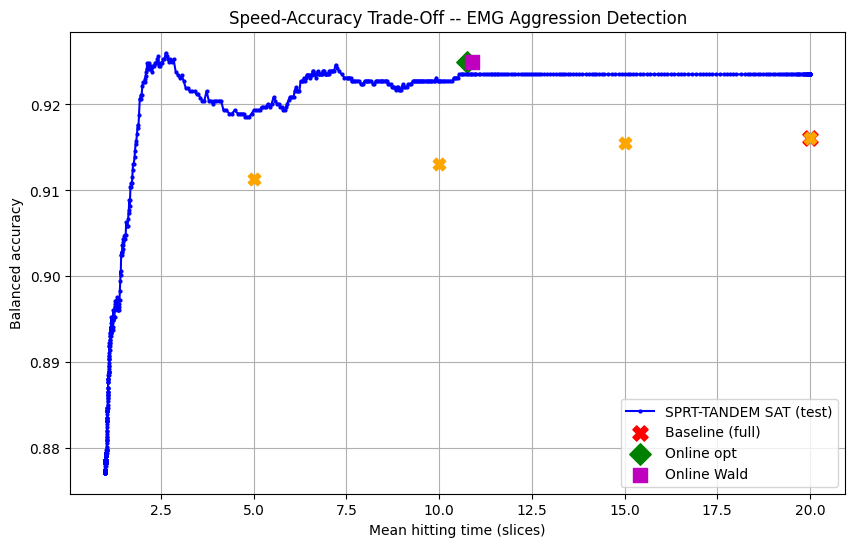

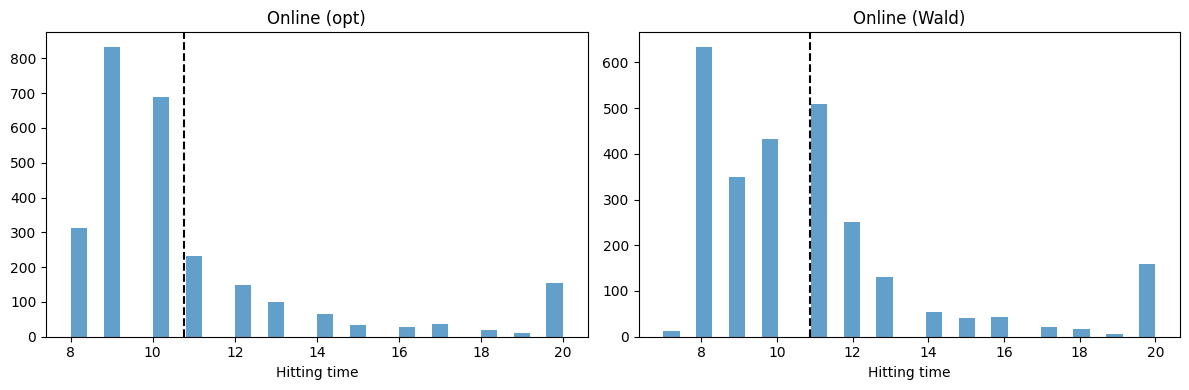

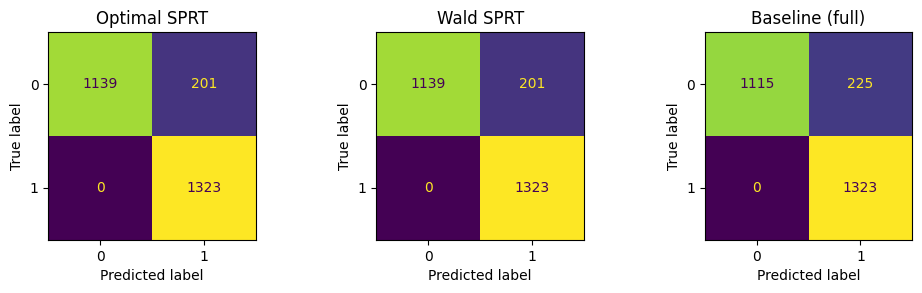

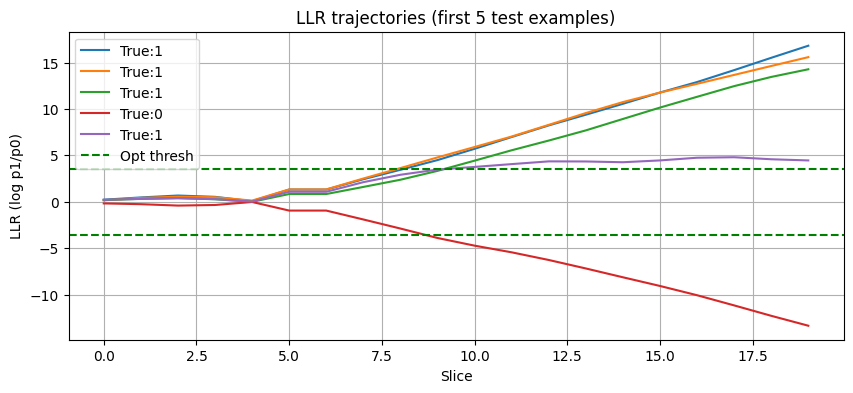

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(mhts_test, baccs_test, 'b-o', markersize=2, label='SPRT-TANDEM SAT (test)')
for k, res in baseline_results.items():
    plt.scatter(k, res['Bal.Acc'], color='orange', marker='X', s=80, zorder=5)
plt.scatter([T], [metrics_base['Bal.Acc']], color='r', marker='X', s=120,
            label='Baseline (full)')
plt.scatter([metrics_opt['Mean HT']], [metrics_opt['Bal.Acc']],
            color='g', marker='D', s=120, label='Online opt')
plt.scatter([metrics_wald['Mean HT']], [metrics_wald['Bal.Acc']],
            color='m', marker='s', s=100, label='Online Wald')
plt.xlabel('Mean hitting time (slices)')
plt.ylabel('Balanced accuracy')
plt.title('Speed-Accuracy Trade-Off -- EMG Aggression Detection')
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hts_opt, bins=30, alpha=0.7, label='Optimal threshold')
axes[0].axvline(np.mean(hts_opt), color='k', linestyle='--')
axes[0].set_xlabel('Hitting time')
axes[0].set_title('Online (opt)')
axes[1].hist(hts_wald, bins=30, alpha=0.7, label='Wald threshold')
axes[1].axvline(np.mean(hts_wald), color='k', linestyle='--')
axes[1].set_xlabel('Hitting time')
axes[1].set_title('Online (Wald)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
ConfusionMatrixDisplay.from_predictions(y_test_seq, preds_opt, ax=axes[0], colorbar=False)
axes[0].set_title('Optimal SPRT')
ConfusionMatrixDisplay.from_predictions(y_test_seq, preds_wald, ax=axes[1], colorbar=False)
axes[1].set_title('Wald SPRT')
ConfusionMatrixDisplay.from_predictions(labs_base, preds_base, ax=axes[2], colorbar=False)
axes[2].set_title('Baseline (full)')
plt.tight_layout()
plt.show()

test_llr_list = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        _, logits, _ = integrator(xb)
        llrs = calc_llrs(logits, ORDER, T, NUM_CLASSES)
        test_llr_list.append(llrs[:, :, 1, 0].cpu().numpy())
llr_all = np.concatenate(test_llr_list, axis=0)
plt.figure(figsize=(10, 4))
for i in np.random.randint(0, len(y_test_seq), size=5):
    plt.plot(range(T), llr_all[i], label=f"True:{y_test_seq[i]}")
plt.axhline(y=a_opt, color='g', linestyle='--', label='Opt thresh')
plt.axhline(y=-a_opt, color='g', linestyle='--')
plt.xlabel('Slice')
plt.ylabel('LLR (log p1/p0)')
plt.title('LLR trajectories (first 5 test examples)')
plt.legend()
plt.grid(True)
plt.show()

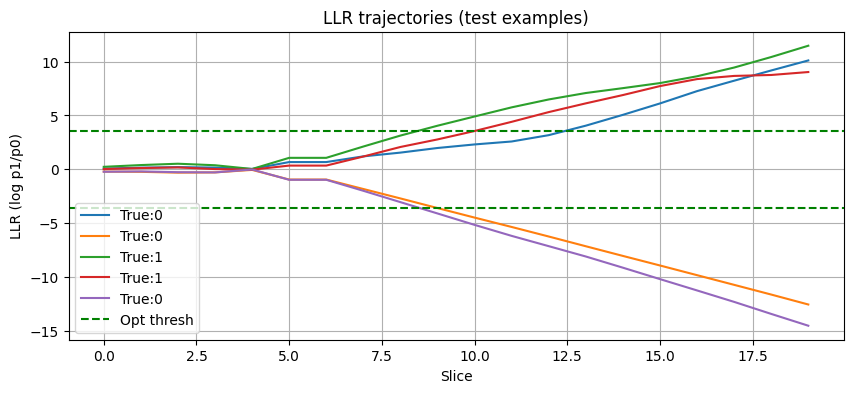

In [51]:
test_llr_list = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        _, logits, _ = integrator(xb)
        llrs = calc_llrs(logits, ORDER, T, NUM_CLASSES)
        test_llr_list.append(llrs[:, :, 1, 0].cpu().numpy())
llr_all = np.concatenate(test_llr_list, axis=0)
plt.figure(figsize=(10, 4))
for i in np.random.randint(0, len(y_test_seq), size=5):
    plt.plot(range(T), llr_all[i], label=f"True:{y_test_seq[i]}")
plt.axhline(y=a_opt, color='g', linestyle='--', label='Opt thresh')
plt.axhline(y=-a_opt, color='g', linestyle='--')
plt.xlabel('Slice')
plt.ylabel('LLR (log p1/p0)')
plt.title('LLR trajectories (test examples)')
plt.legend()
plt.grid(True)
plt.show()